In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
from math import sqrt, ceil
import os


In [90]:
def plot_kdes(base_path: str, train_grid: List[int], test_grid: List[int], mode = 'indep'):
    '''
    mode = indep or true_dist
    '''        
    n = len(train_grid) * len(test_grid)
    rows = ceil(sqrt(n))
    cols = ceil(n / rows)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    
    axes_flat = axes.ravel()

    paths = [f'{base_path}/{train_idx}_{test_idx}_test_preprocessed.parquet' for train_idx in train_grid for test_idx in test_grid]
    
    for idx, path in enumerate(paths):
        filename = os.path.splitext(os.path.basename(path))[0]
        
        df = pd.read_parquet(path)
        df['duration'] = df['max_lifetime'] - df['time']
        df = df[df['duration'] != 0]
        if mode == 'true_dist':
            df = df[df['time'] == df.groupby('serial_number')['time'].transform('min')] # Только время от первого вхождения до последнего
        print(f"path: {path}, mean_duration: {df['duration'].mean()}, cens_mean: {df[df['failure'] == 0]['duration'].mean()}, term_mean: {df[df['failure'] == 1]['duration'].mean()}")
        sns.kdeplot(df, x='duration', hue='failure', ax=axes_flat[idx])
        
        axes_flat[idx].set_title(filename, fontsize=10, pad=5)
        
        axes_flat[idx].grid(True, alpha=0.3)
        axes_flat[idx].set_xlabel('Duration', fontsize=8)
        axes_flat[idx].set_ylabel('Density', fontsize=8)
        axes_flat[idx].tick_params(labelsize=8)

    # for idx in range(n, rows*cols):
    #     axes_flat[idx].axis('off')
    
    plt.tight_layout()
    return fig

path: Preprocessed_EP/1_1_test_preprocessed.parquet, mean_duration: 1164.3263274336284, cens_mean: 1241.7431421446383, term_mean: 555.6176470588235
path: Preprocessed_EP/1_250_test_preprocessed.parquet, mean_duration: 1164.3263274336284, cens_mean: 1241.7431421446383, term_mean: 555.6176470588235
path: Preprocessed_EP/1_500_test_preprocessed.parquet, mean_duration: 1164.3263274336284, cens_mean: 1241.7431421446383, term_mean: 555.6176470588235


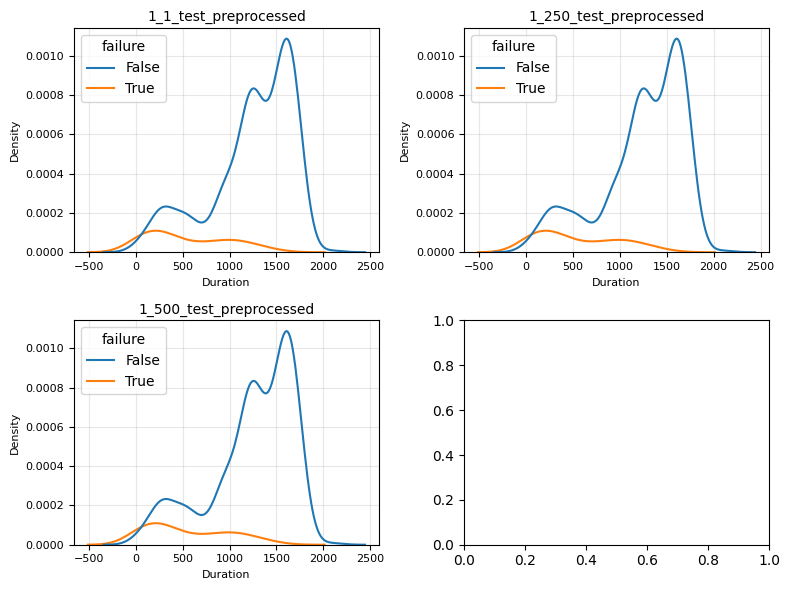

In [91]:
fig = plot_kdes('Preprocessed_EP', [1], [1, 250, 500], mode = 'true_dist')

path: Preprocessed_EP/1_1_test_preprocessed.parquet, mean_duration: 1164.3263274336284, cens_mean: 1241.7431421446383, term_mean: 555.6176470588235
path: Preprocessed_EP/1_250_test_preprocessed.parquet, mean_duration: 605.2654302052478, cens_mean: 633.6868387899762, term_mean: 334.8050072219547


path: Preprocessed_EP/1_500_test_preprocessed.parquet, mean_duration: 627.5660783800464, cens_mean: 650.0130479401847, term_mean: 378.5403851180622


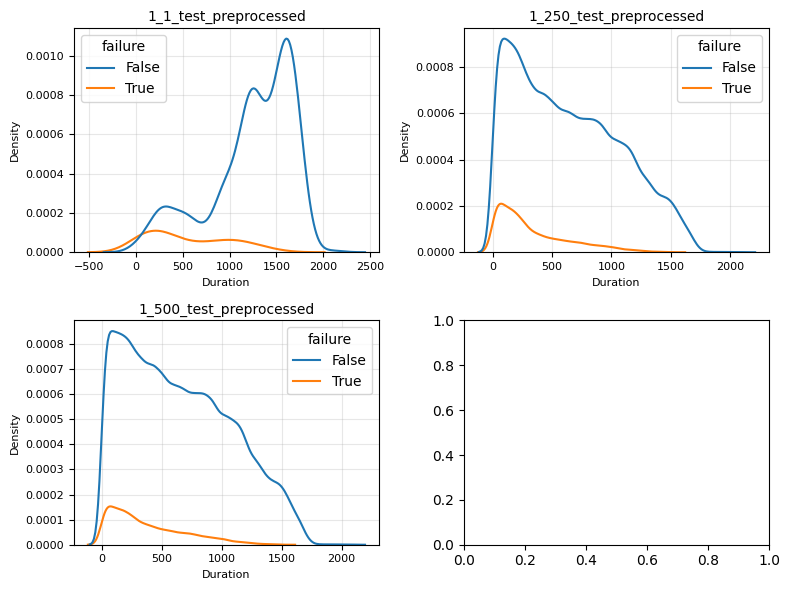

In [92]:
fig = plot_kdes('Preprocessed_EP', [1], [1, 250, 500], mode = 'indep')

In [93]:
paths_train = ['Preprocessed_new/1_train_preprocessed.csv', 
         'Preprocessed_new/2_train_preprocessed.csv',
         'Preprocessed_new/5_train_preprocessed.csv',
         'Preprocessed_new/10_train_preprocessed.csv', 
         'Preprocessed_new/15_train_preprocessed.csv',
         'Preprocessed_new/20_train_preprocessed.csv',
         'Preprocessed_new/30_train_preprocessed.csv', 
         'Preprocessed_new/40_train_preprocessed.csv',
         'Preprocessed_new/50_train_preprocessed.csv']
train_samples = [1, 2, 5, 10, 15, 20, 30, 40, 50]

In [94]:
fig = plot_kdes(paths_train)


TypeError: plot_kdes() missing 2 required positional arguments: 'train_grid' and 'test_grid'

In [ ]:
def get_stats(paths, train_samples):
    df = pd.DataFrame(columns=['train_samples', 
                               'total_cnt',
                               'cens_p',
                               'term_p'])
    for cur_train_samples, path in zip(train_samples, paths):
        cur_df = pd.read_csv(path)
        total_cnt = cur_df.shape[0]
        cens_cnt = cur_df[cur_df['failure'] == 0]['failure'].shape[0]
        term_cnt = cur_df[cur_df['failure'] == 1]['failure'].shape[0]
        df.loc[len(df)] = [cur_train_samples, total_cnt, cens_cnt / total_cnt, term_cnt / total_cnt]
    return df

In [ ]:
stats = get_stats(paths_train, train_samples)

In [ ]:
stats

,train_samples,total_cnt,cens_p,term_p
0,1.0,34744.0,0.866250,0.133750
1,2.0,52089.0,0.866555,0.133445
2,5.0,103882.0,0.866964,0.133036
3,10.0,189707.0,0.867712,0.132288
4,15.0,275101.0,0.868143,0.131857
5,20.0,359943.0,0.868535,0.131465
6,30.0,528457.0,0.869291,0.130709
7,40.0,695932.0,0.870109,0.129891
8,50.0,862304.0,0.871076,0.128924


# KDE распределения времени жизни

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
from math import sqrt, ceil
import os


In [ ]:
df = pd.read_csv('Preprocessed_new/50_train_preprocessed.csv')

In [ ]:
df = df.sort_values(by=['serial_number', 'time'])

In [ ]:
df['duration'] = df['max_lifetime'] - df['time']
# df['terminal_event'] = df.groupby('id')['event'].transform('max')

In [ ]:
df['Отказ'] = df['failure']
df_1 = df.groupby('serial_number').head(1)
df_10 = df.groupby('serial_number').head(10)
df_25 = df.groupby('serial_number').head(25)
# df_1 = df.groupby('serial_number').sample(1)
# df_10 = df.groupby('serial_number').sample(10, replace=True)
# df_25 = df.groupby('serial_number').sample(25, replace=True)

In [ ]:
# df_1.loc[df_1['time'] == df_1.groupby('id')['time'].transform('max'), 'event'] = df_1['terminal_event']
# df_10.loc[df_10['time'] == df_10.groupby('id')['time'].transform('max'), 'event'] = df_10['terminal_event']
# df_25.loc[df_25['time'] == df_25.groupby('id')['time'].transform('max'), 'event'] = df_25['terminal_event']


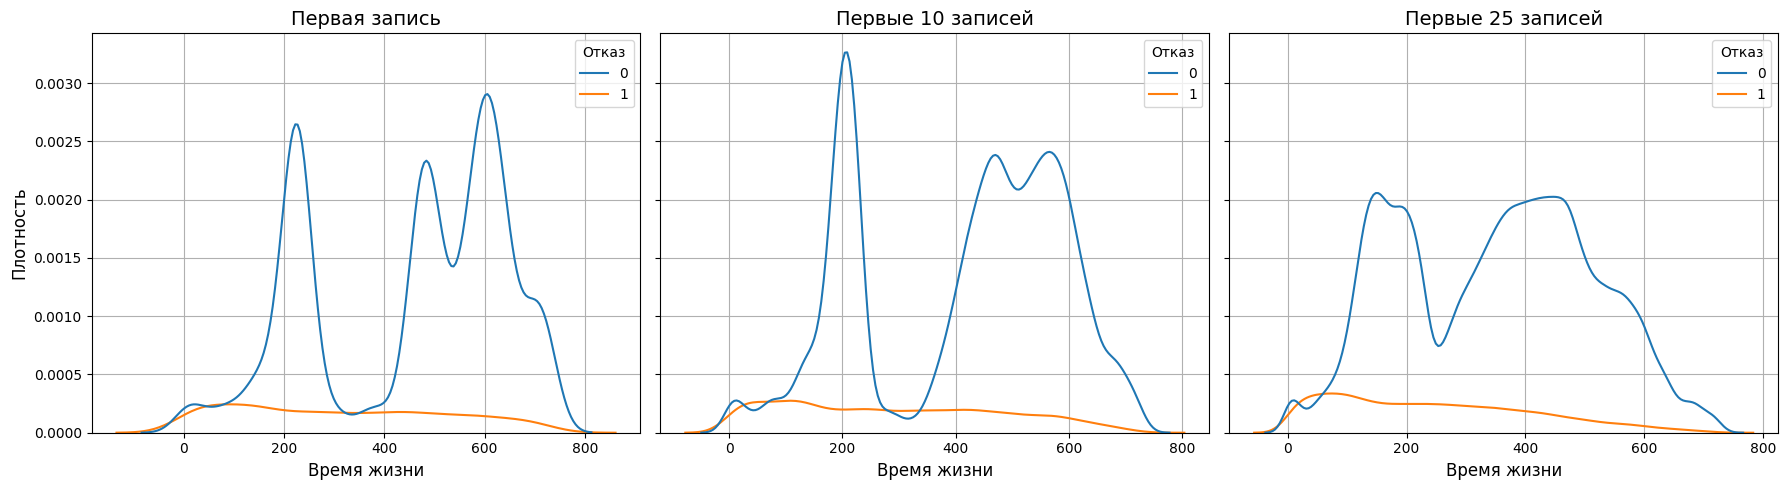

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

data_list = [df_1, df_10, df_25]
titles = ['Первая запись', 'Первые 10 записей', 'Первые 25 записей']

for i, (data, title) in enumerate(zip(data_list, titles)):
    ax = axes[i]
    sns.kdeplot(data=data, x='duration', hue='Отказ', ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Время жизни', fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)
    # ax.legend(title='Отказ', title_fontsize=11, fontsize=10)
    ax.grid(True)

plt.tight_layout()
plt.show()